# Lung Cancer Prediction - Capstone

Using the actual survey_lung_cancer.csv dataset (309 patients, symptom/lifestyle survey) since that's the real dataset behind the example. Comparing Logistic Regression, KNN, Decision Tree, SVM, Naive Bayes and Random Forest.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

## Loading the data

In [2]:
lung_data = pd.read_csv("survey_lung_cancer.csv")
lung_data.shape

(309, 16)

In [3]:
lung_data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [4]:
lung_data.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

no missing values, clean dataset.

In [5]:
lung_data['LUNG_CANCER'].value_counts(normalize=True)

LUNG_CANCER
YES    0.873786
NO     0.126214
Name: proportion, dtype: float64

this is pretty imbalanced - 87% YES vs 13% NO. keeping this in mind for later since accuracy alone can look good here just by predicting YES most of the time.

## Encoding

In [6]:
lung_data["GENDER"] = lung_data["GENDER"].map({"M": 0, "F": 1})
lung_data["LUNG_CANCER"] = lung_data["LUNG_CANCER"].map({"YES": 1, "NO": 0})
lung_data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,0,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,0,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,1,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,0,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,1,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


## Features and target

In [7]:
x = lung_data.iloc[:, :-1]
y = lung_data["LUNG_CANCER"]
x.shape, y.shape

((309, 15), (309,))

## Scaling

AGE goes from 21 to 87 while everything else is coded 1/2, so scaling before KNN/SVM since those are distance/margin based and would otherwise be dominated by AGE.

In [8]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)
x_scaled.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,-0.952579,0.771850,-1.135292,0.869300,1.003241,-1.003241,-1.009756,0.696833,-1.120480,0.892475,0.892475,0.852207,0.748736,1.063501,0.892475
1,-0.952579,1.381829,0.880830,-1.150351,-0.996769,-1.003241,0.990338,0.696833,0.892475,-1.120480,-1.120480,-1.173424,0.748736,1.063501,0.892475
2,1.049781,-0.448107,-1.135292,-1.150351,-0.996769,0.996769,-1.009756,0.696833,-1.120480,0.892475,-1.120480,0.852207,0.748736,-0.940291,0.892475
3,-0.952579,0.039876,0.880830,0.869300,1.003241,-1.003241,-1.009756,-1.435063,-1.120480,-1.120480,0.892475,-1.173424,-1.335584,1.063501,0.892475
4,1.049781,0.039876,-1.135292,0.869300,-0.996769,-1.003241,-1.009756,-1.435063,-1.120480,0.892475,-1.120480,0.852207,0.748736,-0.940291,-1.120480


In [9]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=1/3, random_state=0)
x_train.shape, x_test.shape

((206, 15), (103, 15))

## Training the models

In [10]:
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(x_train, y_train)
prediction1 = log_reg.predict(x_test)

In [11]:
knn = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2)
knn.fit(x_train, y_train)
prediction2 = knn.predict(x_test)

In [12]:
tree = DecisionTreeClassifier(random_state=0, criterion="entropy")
tree.fit(x_train, y_train)
prediction3 = tree.predict(x_test)

simplifying the SVM here - going with a plain SVC instead of wrapping it in OneVsRestClassifier + BaggingClassifier, since this is a binary problem (OneVsRest is for multi-class) and the bagging wrapper wasn't really doing anything explained.

In [13]:
svm = SVC(kernel='rbf', C=10, probability=True, random_state=9)
svm.fit(x_train, y_train)
prediction4 = svm.predict(x_test)

In [14]:
nb = GaussianNB()
nb.fit(x_train, y_train)
prediction5 = nb.predict(x_test)

random forest wasn't one of the individually covered algorithm modules (KNN/Decision Tree/Naive Bayes/SVM), keeping it anyway since it was part of the course's own example and it's a pretty standard extension of decision trees.

In [15]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(x_train, y_train)
prediction6 = rf_classifier.predict(x_test)

## Evaluation

In [16]:
def evaluate_model(y_true, y_pred, model_name, results_dict):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    results_dict[model_name] = accuracy
    print(f"{model_name} Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}\n")

In [17]:
accuracy_results = {}
evaluate_model(y_test, prediction1, "Logistic Regression", accuracy_results)
evaluate_model(y_test, prediction2, "KNN", accuracy_results)
evaluate_model(y_test, prediction3, "Decision Tree", accuracy_results)
evaluate_model(y_test, prediction4, "SVM", accuracy_results)
evaluate_model(y_test, prediction5, "Naive Bayes", accuracy_results)
evaluate_model(y_test, prediction6, "Random Forest", accuracy_results)

Logistic Regression Metrics:
Accuracy: 0.8932
Precision: 0.9043
Recall: 0.9770
F1 Score: 0.9392

KNN Metrics:
Accuracy: 0.8641
Precision: 0.9011
Recall: 0.9425
F1 Score: 0.9213

Decision Tree Metrics:
Accuracy: 0.8641
Precision: 0.9195
Recall: 0.9195
F1 Score: 0.9195

SVM Metrics:
Accuracy: 0.8738
Precision: 0.9111
Recall: 0.9425
F1 Score: 0.9266

Naive Bayes Metrics:
Accuracy: 0.8641
Precision: 0.9101
Recall: 0.9310
F1 Score: 0.9205

Random Forest Metrics:
Accuracy: 0.8932
Precision: 0.9043
Recall: 0.9770
F1 Score: 0.9392



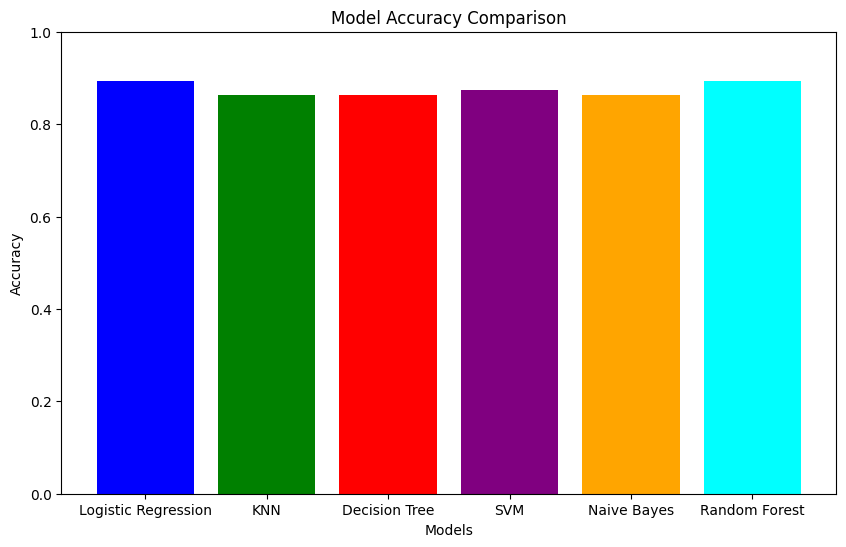

In [18]:
plt.figure(figsize=(10, 6))
plt.bar(accuracy_results.keys(), accuracy_results.values(), color=['blue', 'green', 'red', 'purple', 'orange', 'cyan'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.show()

## Checking the imbalance issue properly

accuracy alone doesn't tell us much when 87% of the data is already YES - a model that just predicts YES every time would score around there without learning anything. checking macro-averaged precision/recall/f1 instead (treats both classes equally) plus each model's confusion matrix to see how many of the actual NO cases each one caught.

In [19]:
from sklearn.metrics import precision_score as prec_score, recall_score as rec_score, f1_score as f1_scr

predictions = {
    'Logistic Regression': prediction1,
    'KNN': prediction2,
    'Decision Tree': prediction3,
    'SVM': prediction4,
    'Naive Bayes': prediction5,
    'Random Forest': prediction6
}

for name, pred in predictions.items():
    macro_p = prec_score(y_test, pred, average='macro')
    macro_r = rec_score(y_test, pred, average='macro')
    macro_f1 = f1_scr(y_test, pred, average='macro')
    print(f"{name} - macro precision: {macro_p:.3f}, macro recall: {macro_r:.3f}, macro F1: {macro_f1:.3f}")

Logistic Regression - macro precision: 0.841, macro recall: 0.707, macro F1: 0.750
KNN - macro precision: 0.742, macro recall: 0.690, macro F1: 0.711
Decision Tree - macro precision: 0.741, macro recall: 0.741, macro F1: 0.741
SVM - macro precision: 0.763, macro recall: 0.721, macro F1: 0.739
Naive Bayes - macro precision: 0.741, macro recall: 0.716, macro F1: 0.727
Random Forest - macro precision: 0.841, macro recall: 0.707, macro F1: 0.750


## Confusion Matrices

In [20]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

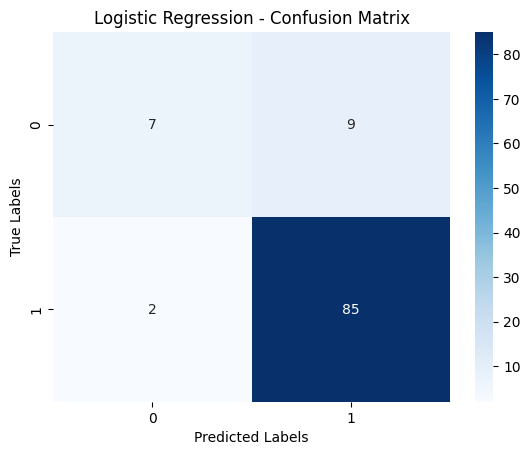

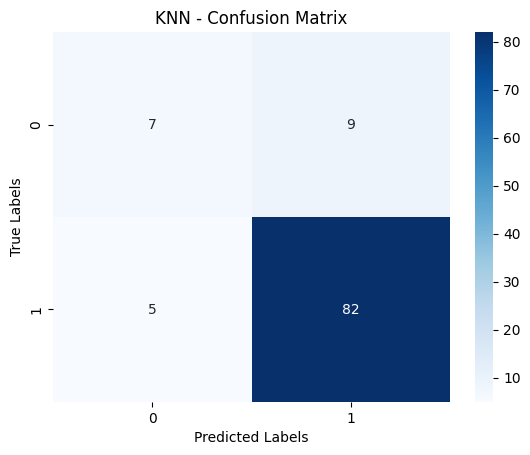

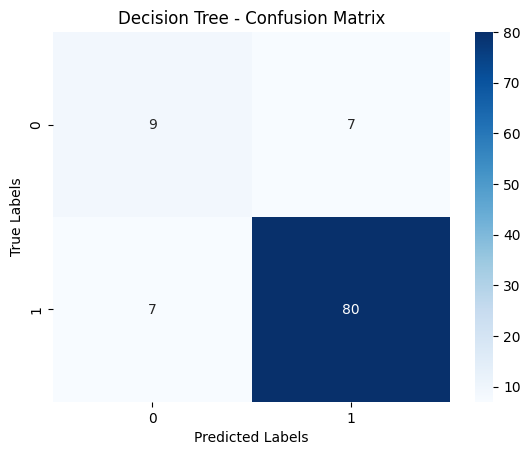

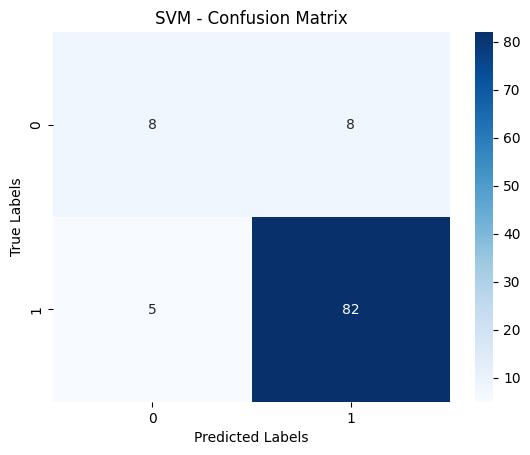

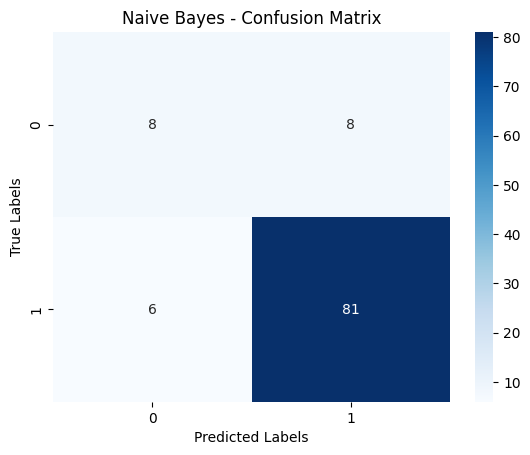

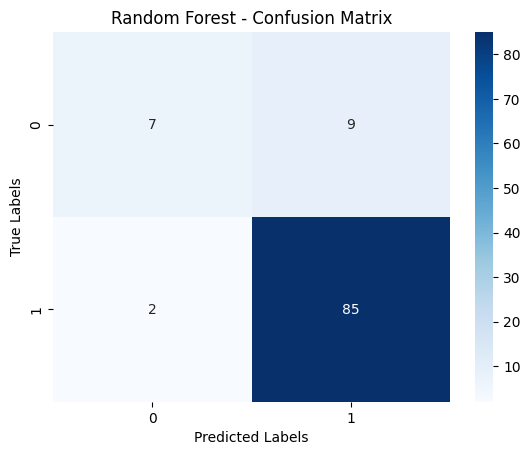

In [21]:
plot_confusion_matrix(y_test, prediction1, "Logistic Regression")
plot_confusion_matrix(y_test, prediction2, "KNN")
plot_confusion_matrix(y_test, prediction3, "Decision Tree")
plot_confusion_matrix(y_test, prediction4, "SVM")
plot_confusion_matrix(y_test, prediction5, "Naive Bayes")
plot_confusion_matrix(y_test, prediction6, "Random Forest")

## Correlation Heatmap

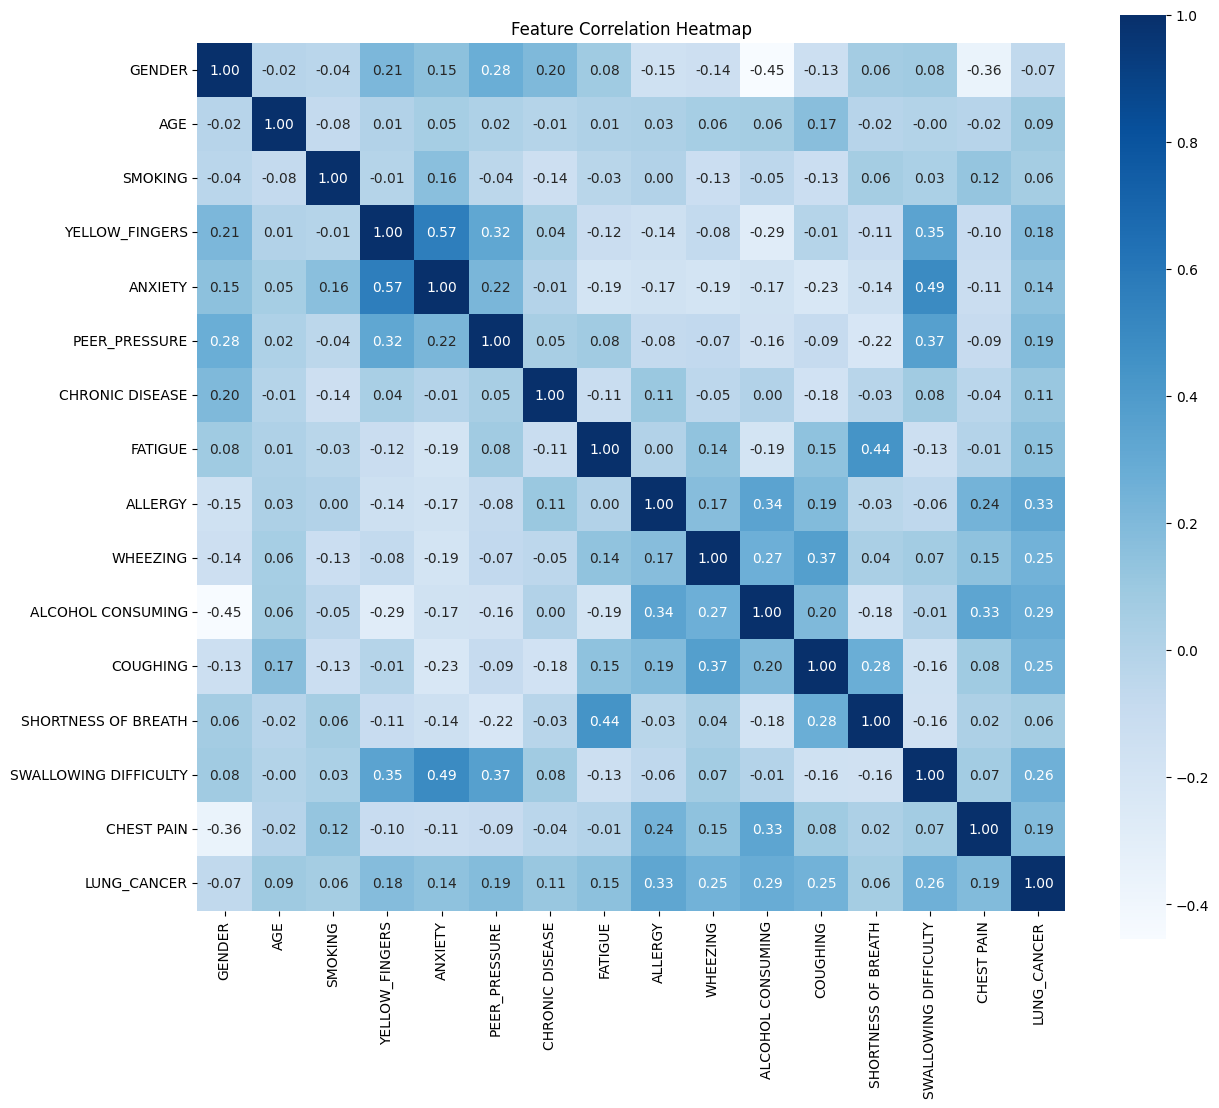

In [22]:
correlation = lung_data.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(correlation, cmap="Blues", annot=True, square=True, fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

## Feature Distributions

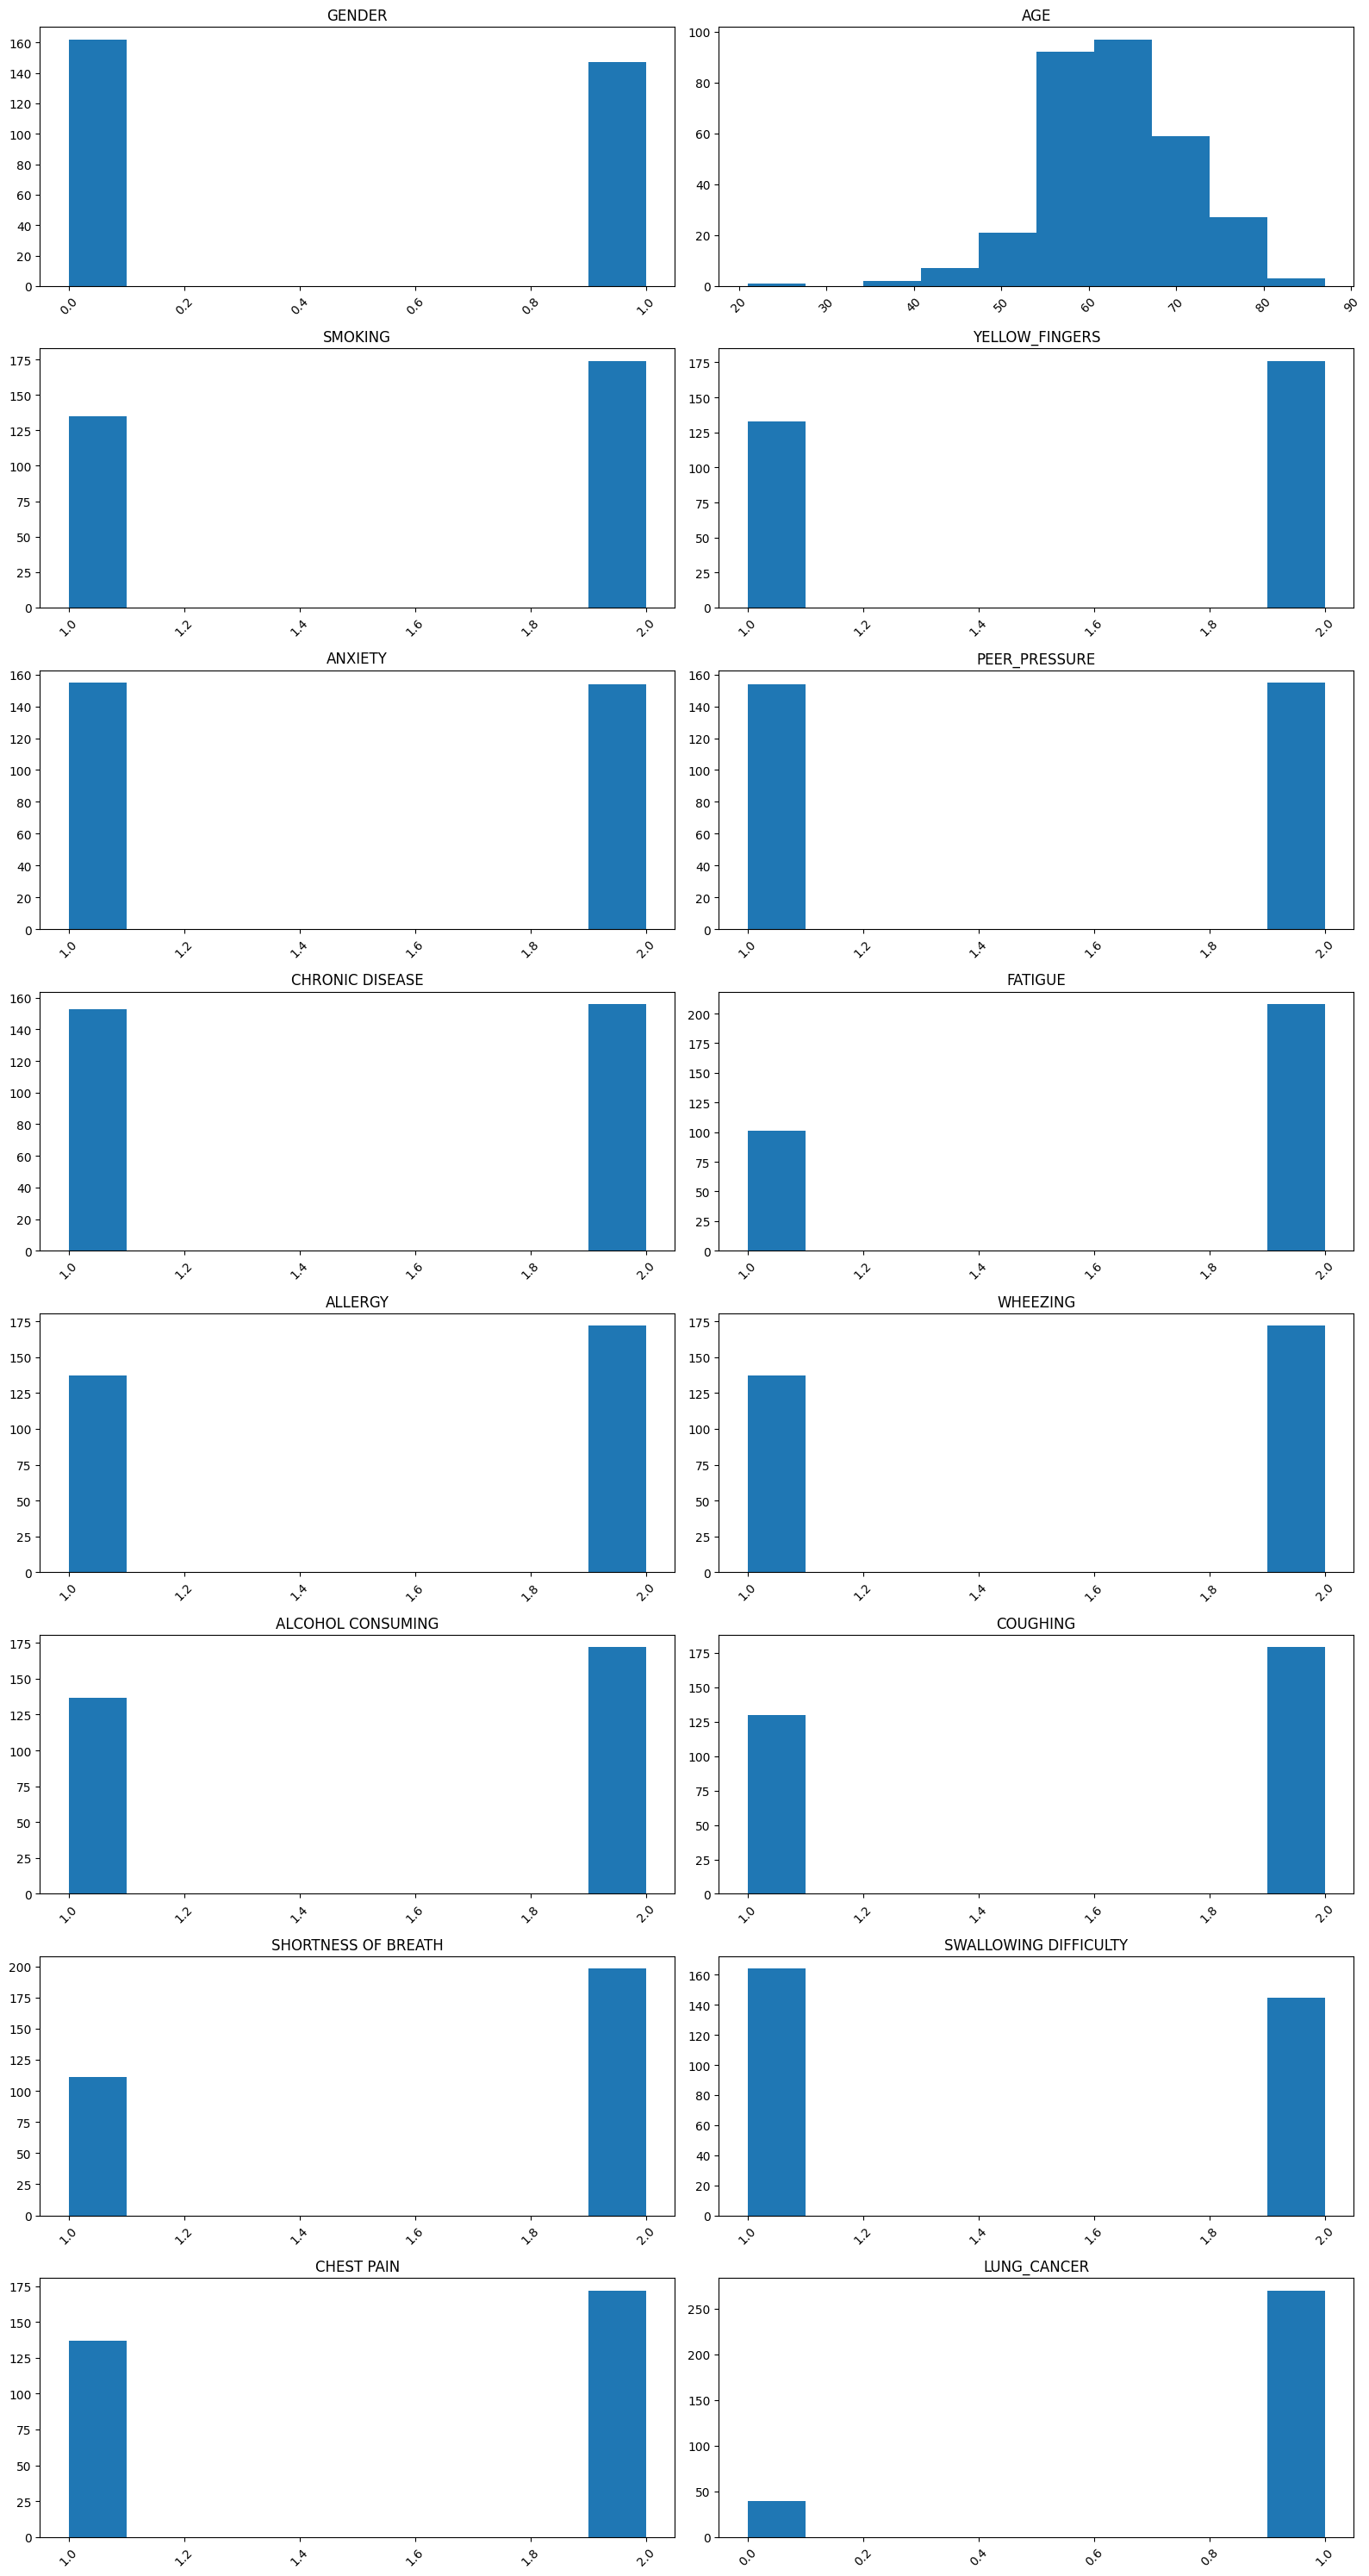

In [23]:
num_list = list(lung_data.columns)
rows = (len(num_list) // 2) + (len(num_list) % 2)
plt.figure(figsize=(16, 30))
for i in range(len(num_list)):
    plt.subplot(rows, 2, i + 1)
    plt.title(num_list[i])
    plt.xticks(rotation=45)
    plt.hist(lung_data[num_list[i]])
plt.tight_layout()
plt.show()

## Insights

Accuracy looked decent across the board (86-89%), but that's not saying much here since the test set is 87 YES vs only 16 NO - just guessing YES for everyone would land around 84% accuracy without learning anything. The macro-averaged scores tell a more honest story: macro F1 sits in the 0.71-0.75 range for every model, noticeably lower than the 0.92-0.94 F1 the same models get when only scored on the YES class. Logistic Regression and Random Forest tied for the best macro scores (0.841 precision, 0.707 recall, 0.750 F1).

Looking at the actual confusion matrices, out of the 16 real NO (cancer-free) cases in the test set: Logistic Regression, KNN and Random Forest each correctly caught 7 of them, SVM and Naive Bayes caught 8, and Decision Tree caught the most at 9. So even the best model here is only catching about half the actual healthy patients, the rest get incorrectly flagged as having cancer. On the other side, Logistic Regression and Random Forest missed only 2 real cancer cases each (the fewest false negatives), while Decision Tree missed 7, which is a lot for a screening context where missing an actual cancer patient is the costlier mistake.

So there's a real precision/recall trade-off between the models here rather than one being flatly "the best" - Decision Tree is better at correctly clearing healthy patients, Logistic Regression/Random Forest are better at not missing actual cancer cases. Given this is framed as cancer screening, I'd lean toward Logistic Regression or Random Forest since missing a real case (false negative) is generally worse than a false alarm that gets ruled out with follow-up testing, but that's a judgment call depending on what the model is actually used for.

Switching from the course example's original setup, adding feature scaling also changed the SVM's behavior specifically - before scaling (when just running the original notebook as-is) the SVM's precision matched almost exactly the class prior with recall at 1.0, a sign it was probably just predicting YES for every single test case. After scaling, its numbers moved to a more normal 91% precision / 94% recall, actually distinguishing between classes rather than defaulting to the majority label. Given AGE is on such a different scale from the mostly 1/2-coded symptom columns, this tracks - distance/margin based models like SVM and KNN are sensitive to that kind of scale mismatch.

Overall, the take-home point for a lung cancer screening tool built on this kind of survey data: solid overall accuracy numbers can hide the fact that the minority class (healthy patients, in this case) is much harder to correctly identify with only 39 NO examples in the whole 309-row dataset to learn from. A real deployment would need a lot more negative examples and probably techniques for handling class imbalance (like class weighting or oversampling) beyond what any of the course modules cover, to get genuinely reliable performance on both classes rather than just the majority one.